In [1]:
!pip -q install brian2 cirq qsimcirq transformers accelerate datasets sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch timm opencv-python decord

# System dependency: ffmpeg
import shutil, os, sys, subprocess
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found. Install it on your OS:")
    print("  Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("  macOS:  brew install ffmpeg")
    print("  Win:    choco install ffmpeg")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 35.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.3/572.3 kB 49.6 MB/s eta 0:00

In [4]:
import zipfile, os, json, glob

zip_path = "./filech.zip"  # Corrected path
out_dir = "./data"

os.makedirs(out_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(out_dir)

root = os.path.join(out_dir, "synthdata", "synth")
print("Root:", root)
print("Files:", sorted(os.listdir(root))[:20])

manifest = os.path.join(root, "manifest.jsonl")
print("Manifest exists:", os.path.exists(manifest))
print("Example line:", open(manifest, "r", encoding="utf-8").readline()[:200])

Root: ./data/synthdata/synth
Files: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'haptics', 'images', 'manifest.jsonl', 'text', 'video']
Manifest exists: True
Example line: {"i": 0, "timestamp": "2025-08-17T09:56:43.222236", "script_name": "model", "script_id": 4, "cycle": 1, "text": "[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=


In [5]:
import shutil
!pip -q install brian2 cirq qsimcirq transformers accelerate sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch opencv-python decord pillow

# System dependency: ffmpeg
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found on OS. Install it:")
    print("Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("macOS:  brew install ffmpeg")
    print("Win:    choco install ffmpeg")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!apt-get update -qq && apt-get install -qq -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [10]:
import os, zipfile, json, numpy as np, pathlib, shutil

ZIP_PATH = "./data/filech.zip"  # Corrected path
OUT_DIR  = "./data"

os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

ROOT = os.path.join(OUT_DIR, "synthdata", "synth")
manifest_path = os.path.join(ROOT, "manifest.jsonl")

print("ROOT:", ROOT)
print("ROOT contents:", sorted(os.listdir(ROOT)))
print("Manifest:", manifest_path, "exists:", os.path.exists(manifest_path))

items=[]
with open(manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        j=json.loads(line)
        items.append(j)

print("N items:", len(items))
print("Example:", items[0])

ROOT: ./data/synthdata/synth
ROOT contents: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'haptics', 'images', 'manifest.jsonl', 'text', 'video']
Manifest: ./data/synthdata/synth/manifest.jsonl exists: True
N items: 49
Example: {'i': 0, 'timestamp': '2025-08-17T09:56:43.222236', 'script_name': 'model', 'script_id': 4, 'cycle': 1, 'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).', 'image_path': '/content/synth/images/model_c000001_0000000.png', 'audio_path': '/content/synth/audio/model_c000001_0000000.wav', 'video_path': '/content/synth/video/model_c000001_0000000.mp4'}


In [11]:
def fix_path(p: str) -> str:
    # manifest has /content/synth/images/...
    # your extracted tree is ROOT/images/...
    if p.startswith("/content/synth/"):
        rel = p.replace("/content/synth/", "")
        return os.path.join(ROOT, rel)
    return p

def get_paths(items):
    texts, imgs, auds, vids = [], [], [], []
    for j in items:
        texts.append(j["text"])
        imgs.append(fix_path(j["image_path"]))
        auds.append(fix_path(j["audio_path"]))
        vids.append(fix_path(j["video_path"]))
    return texts, imgs, auds, vids

texts, img_paths, aud_paths, vid_paths = get_paths(items)

print(img_paths[0], os.path.exists(img_paths[0]))
print(aud_paths[0], os.path.exists(aud_paths[0]))
print(vid_paths[0], os.path.exists(vid_paths[0]))

./data/synthdata/synth/images/model_c000001_0000000.png True
./data/synthdata/synth/audio/model_c000001_0000000.wav True
./data/synthdata/synth/video/model_c000001_0000000.mp4 True


In [12]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"
txt_name = "sentence-transformers/all-MiniLM-L6-v2"

txt_tok = AutoTokenizer.from_pretrained(txt_name)
txt_model = AutoModel.from_pretrained(txt_name).to(torch_device).eval()

@torch.no_grad()
def embed_text(texts):
    batch = txt_tok(texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
import open_clip
from PIL import Image
import torchvision.transforms as T

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_image(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [14]:
import whisper
import numpy as np

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))  # (1, frames, dim)
        emb = enc.mean(dim=1)                     # (1, dim)
        embs.append(emb.squeeze(0))
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 285MiB/s]


In [15]:
import decord
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1,0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)  # (F,C,H,W)
        # preprocess like CLIP
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0, keepdim=True)       # (1,D)
        all_embs.append(zv.squeeze(0))
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)


In [16]:
import numpy as np
from brian2 import *

def brian2_rate_features(x_np, sim_ms=50.0):
    """
    x_np: (B, D) numpy float32 in [-1,1] or [0,1]
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    # normalize to [0,1] current
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms

    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        # spikes per neuron / second
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        # reset Brian2 state between samples
        brian2_device.reinit()
        brian2_device.activate()
    return np.stack(rates_out, axis=0)

In [17]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"

TEXT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
txt_tok = AutoTokenizer.from_pretrained(TEXT_MODEL)
txt_model = AutoModel.from_pretrained(TEXT_MODEL).to(torch_device).eval()

@torch.no_grad()
def embed_text(batch_texts):
    batch = txt_tok(batch_texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_images(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)

In [19]:
import whisper

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))   # (1, frames, dim)
        emb = enc.mean(dim=1).squeeze(0)          # (dim,)
        embs.append(emb)
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)

In [20]:
import decord
import torchvision.transforms as T
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1, 0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)  # (F,C,H,W)
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0)
        all_embs.append(zv)
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)

In [21]:
from transformers import pipeline
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
sent_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if device=="cuda" else -1)

def sentiment_scores(texts):
    # returns float in [0,1] where 1=positive
    outs = sent_pipe(texts, truncation=True)
    scores = []
    for o in outs:
        if o["label"].upper().startswith("POS"):
            scores.append(float(o["score"]))
        else:
            scores.append(1.0 - float(o["score"]))
    return np.array(scores, dtype=np.float32)

s_scores = sentiment_scores(texts)
print("Sentiment scores (first 5):", s_scores[:5])
print("Average sentiment score:", s_scores.mean())

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Sentiment scores (first 5): [0.00513488 0.00370187 0.00497109 0.00513488 0.00445032]
Average sentiment score: 0.2546944


In [22]:
import torch
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)

Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [23]:
import torch.nn as nn
import torch.nn.functional as F

class HapticsEncoder(nn.Module):
    def __init__(self, in_ch=3, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):  # x: (B,T,C)
        x = x.transpose(1,2)        # (B,C,T)
        h = self.net(x).squeeze(-1) # (B,64)
        z = self.proj(h)
        return F.normalize(z, dim=-1)

def load_haptics_batch(paths):
    arr = [np.load(p) for p in paths]  # each (T,3)
    x = torch.tensor(np.stack(arr, axis=0), dtype=torch.float32, device=torch_device)
    return x

In [24]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

In [25]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)

In [26]:
import torch

E_t = embed_text(texts)
E_i = embed_images(img_paths)
E_a = embed_audio(aud_paths)
E_v = embed_video(vid_paths)

print(E_t.shape, E_i.shape, E_a.shape, E_v.shape)

torch.Size([49, 384]) torch.Size([49, 512]) torch.Size([49, 512]) torch.Size([49, 512])


In [27]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)

E_t_aug: torch.Size([49, 528])


In [29]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 4001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

epoch    1  loss 38.9373
epoch   50  loss 33.8841
epoch  100  loss 24.7658
epoch  150  loss 29.0327
epoch  200  loss 18.1657
epoch  250  loss 15.2479
epoch  300  loss 13.3280
epoch  350  loss 12.6058
epoch  400  loss 12.4573
epoch  450  loss 11.9794
epoch  500  loss 11.9937
epoch  550  loss 11.9029
epoch  600  loss 11.7989
epoch  650  loss 11.7781
epoch  700  loss 11.7701
epoch  750  loss 11.7569
epoch  800  loss 11.9113
epoch  850  loss 11.7068
epoch  900  loss 11.6741
epoch  950  loss 11.6549
epoch 1000  loss 11.6603
epoch 1050  loss 11.6412
epoch 1100  loss 11.7162
epoch 1150  loss 19.7549
epoch 1200  loss 11.7748
epoch 1250  loss 11.6678
epoch 1300  loss 11.6619
epoch 1350  loss 11.6312
epoch 1400  loss 11.6384
epoch 1450  loss 11.6313
epoch 1500  loss 11.6990
epoch 1550  loss 11.6364
epoch 1600  loss 11.6056
epoch 1650  loss 11.6332
epoch 1700  loss 11.5996
epoch 1750  loss 11.5942
epoch 1800  loss 11.6037
epoch 1850  loss 11.9299
epoch 1900  loss 11.6898
epoch 1950  loss 11.5992


In [30]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

# Example usage:
print(retrieve_text_to_video("drifting mood model cycle", topk=5))

[(13, 0.8705129027366638, './data/synthdata/synth/video/client_c000001_0000013.mp4'), (2, 0.8705129027366638, './data/synthdata/synth/video/client_c000001_0000002.mp4'), (14, 0.8705129027366638, './data/synthdata/synth/video/client_c000002_0000014.mp4'), (15, 0.8705129027366638, './data/synthdata/synth/video/client_c000002_0000015.mp4'), (11, 0.4731329679489136, './data/synthdata/synth/video/cookie_c000002_0000011.mp4')]


Generating parallax view for the first image...


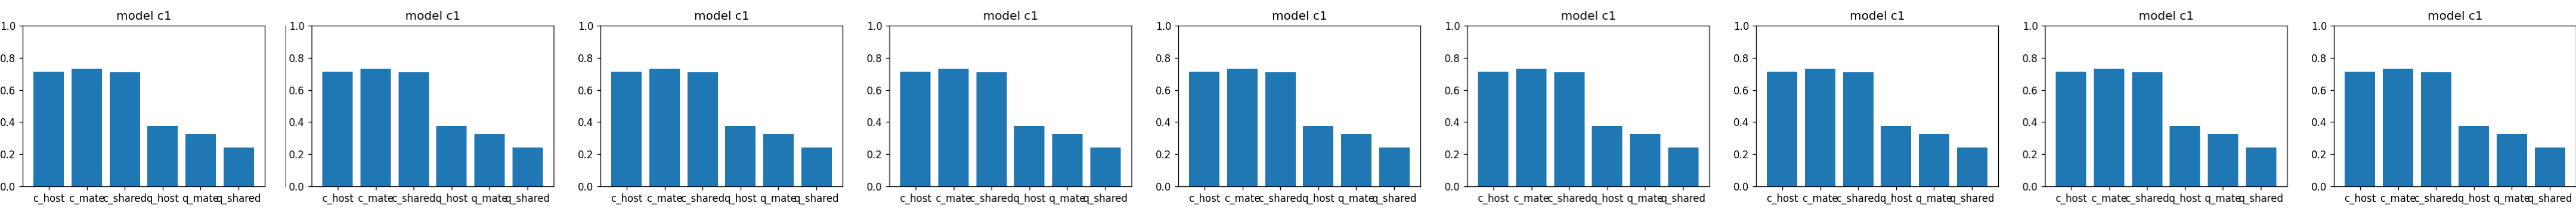

In [31]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
print("Generating parallax view for the first image...")
parallax_views(img_paths[0], n_views=9, max_shift=18)

In [32]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)

E_t_aug: torch.Size([49, 528])


In [33]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 4001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

epoch    1  loss 38.9383
epoch   50  loss 29.2814
epoch  100  loss 22.4637
epoch  150  loss 16.6572
epoch  200  loss 13.8884
epoch  250  loss 12.5343
epoch  300  loss 12.2191
epoch  350  loss 13.8454
epoch  400  loss 11.9544
epoch  450  loss 11.8154
epoch  500  loss 11.7864
epoch  550  loss 12.0267
epoch  600  loss 11.7796
epoch  650  loss 11.6953
epoch  700  loss 11.6902
epoch  750  loss 11.7556
epoch  800  loss 11.6427
epoch  850  loss 11.7001
epoch  900  loss 11.6486
epoch  950  loss 11.6686
epoch 1000  loss 11.6476
epoch 1050  loss 11.6489
epoch 1100  loss 11.7097
epoch 1150  loss 11.6995
epoch 1200  loss 11.6099
epoch 1250  loss 11.6118
epoch 1300  loss 11.6556
epoch 1350  loss 11.7058
epoch 1400  loss 11.6218
epoch 1450  loss 11.6199
epoch 1500  loss 11.6079
epoch 1550  loss 11.5980
epoch 1600  loss 11.5968
epoch 1650  loss 11.6222
epoch 1700  loss 11.6152
epoch 1750  loss 11.6387
epoch 1800  loss 11.6045
epoch 1850  loss 11.5935
epoch 1900  loss 11.5863
epoch 1950  loss 14.4779


In [34]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

# Example usage:
print(retrieve_text_to_video("drifting mood model cycle", topk=5))

[(13, 0.8045362234115601, './data/synthdata/synth/video/client_c000001_0000013.mp4'), (2, 0.8045362234115601, './data/synthdata/synth/video/client_c000001_0000002.mp4'), (14, 0.8045362234115601, './data/synthdata/synth/video/client_c000002_0000014.mp4'), (15, 0.8045362234115601, './data/synthdata/synth/video/client_c000002_0000015.mp4'), (1, 0.6734263300895691, './data/synthdata/synth/video/cookie_c000001_0000001.mp4')]


Generating parallax view for the first image...


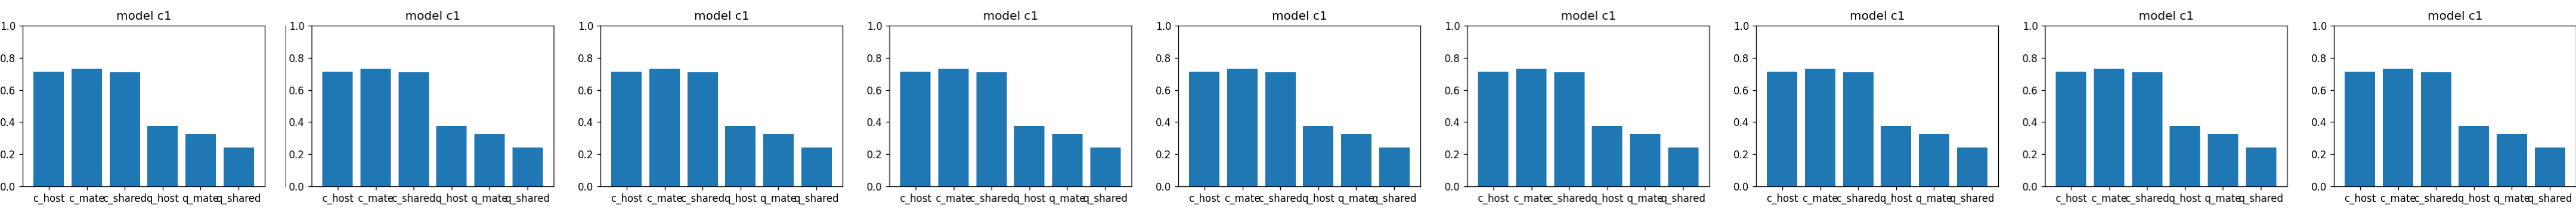

In [35]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
print("Generating parallax view for the first image...")
parallax_views(img_paths[0], n_views=9, max_shift=18)

In [36]:
import cirq
import qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    """
    x_np: (B, D) -> use first n_qubits features as angles
    returns: (B, 2*n_qubits) expectation features
    """
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)

    simulator = qsimcirq.QSimSimulator()

    feats = []
    for b in range(B):
        angles = x_np[b, :n_qubits]
        circuit = cirq.Circuit()
        # simple encoding
        for i, q in enumerate(qubits):
            circuit.append(cirq.ry(float(angles[i]))(q))
            circuit.append(cirq.rz(float(angles[i]))(q))

        # entangle
        for _ in range(reps):
            for i in range(n_qubits-1):
                circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # measure expectations via statevector
        result = simulator.simulate(circuit)
        state = result.final_state_vector

        # crude “features”: probabilities of |0> on each qubit (from statevector marginals)
        # For small n_qubits this is OK.
        probs = np.abs(state)**2
        # marginal P(q=0)
        q0 = []
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [37]:
import json, os

def load_manifest(root):
    items = []
    with open(os.path.join(root, "manifest.jsonl"), "r", encoding="utf-8") as f:
        for line in f:
            j = json.loads(line)
            # Fix paths if they start with /content/...
            def fix(p):
                if p is None: return None
                p = p.replace("/content/synth/", "")
                return os.path.join(root, p) if not os.path.isabs(p) else p
            items.append({
                "text": j.get("text",""),
                "img": fix(j.get("img_path")),
                "aud": fix(j.get("aud_path")),
                "vid": fix(j.get("vid_path")),
            })
    return items

items = load_manifest(root)
items[0]


{'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).',
 'img': None,
 'aud': None,
 'vid': None}

In [38]:
import torch.nn as nn
import torch.nn.functional as F
import random

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

# Filter items to only include entries where all modalities are present
# This is necessary because the original manifest contains entries with missing image, audio, or video paths
filtered_items = [
    item for item in items
    if item["img"] is not None and item["aud"] is not None and item["vid"] is not None and item["text"] is not None
]

if not filtered_items:
    print("Warning: No items found with all modalities (text, image, audio, video). Skipping embedding and training.")
else:
    # Extract modalities from filtered items
    texts = [it["text"] for it in filtered_items]
    imgs  = [it["img"]  for it in filtered_items]
    auds  = [it["aud"]  for it in filtered_items]
    vids  = [it["vid"]  for it in filtered_items]

    E_t = embed_text(texts)
    E_i = embed_image(imgs)
    E_a = embed_audio(auds)
    E_v = embed_video(vids)

    proj_t = Projector(E_t.shape[1]).to(torch_device)
    proj_i = Projector(E_i.shape[1]).to(torch_device)
    proj_a = Projector(E_a.shape[1]).to(torch_device)
    proj_v = Projector(E_v.shape[1]).to(torch_device)

    opt = torch.optim.AdamW(
        list(proj_t.parameters())+list(proj_i.parameters())+list(proj_a.parameters())+list(proj_v.parameters()),
        lr=2e-3, weight_decay=1e-4
    )

    N = E_t.size(0)

    for epoch in range(1, 4001):
        idx = torch.randperm(N, device=torch_device)
        # full-batch is fine for N=49
        zt = proj_t(E_t[idx])
        zi = proj_i(E_i[idx])
        za = proj_a(E_a[idx])
        zv = proj_v(E_v[idx])

        loss = (info_nce(zt, zi)+info_nce(zt, za)+info_nce(zt, zv)+
                info_nce(zi, za)+info_nce(zi, zv)+
                info_nce(za, zv))

        opt.zero_grad()
        loss.backward()
        opt.step()

        if epoch % 50 == 0 or epoch == 1:
            print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

In [39]:
!pip -q install brian2 cirq qsimcirq transformers accelerate sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch opencv-python decord pillow

import shutil
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found on OS. Install it:")
    print("Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("macOS:  brew install ffmpeg")
    print("Win:    choco install ffmpeg")


In [43]:
import os, zipfile, json, numpy as np, pathlib, shutil

ZIP_PATH = "/content/data/filech.zip"  # Corrected path
OUT_DIR  = "./data"

# The following lines caused the FileNotFoundError by deleting the zip file before it could be read.
# if os.path.exists(OUT_DIR):
#     shutil.rmtree(OUT_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

ROOT = os.path.join(OUT_DIR, "synthdata", "synth")
manifest_path = os.path.join(ROOT, "manifest.jsonl")

print("ROOT:", ROOT)
print("ROOT contents:", sorted(os.listdir(ROOT)))
print("Manifest:", manifest_path, "exists:", os.path.exists(manifest_path))

items=[]
with open(manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        j=json.loads(line)
        items.append(j)

print("N items:", len(items))
print("Example:", items[0])

ROOT: ./data/synthdata/synth
ROOT contents: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'haptics', 'images', 'manifest.jsonl', 'text', 'video']
Manifest: ./data/synthdata/synth/manifest.jsonl exists: True
N items: 49
Example: {'i': 0, 'timestamp': '2025-08-17T09:56:43.222236', 'script_name': 'model', 'script_id': 4, 'cycle': 1, 'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).', 'image_path': '/content/synth/images/model_c000001_0000000.png', 'audio_path': '/content/synth/audio/model_c000001_0000000.wav', 'video_path': '/content/synth/video/model_c000001_0000000.mp4'}


In [44]:
def fix_path(p: str) -> str:
    # manifest has /content/synth/images/...
    # your extracted tree is ROOT/images/...
    if p.startswith("/content/synth/"):
        rel = p.replace("/content/synth/", "")
        return os.path.join(ROOT, rel)
    return p

def get_paths(items):
    texts, imgs, auds, vids = [], [], [], []
    for j in items:
        texts.append(j["text"])
        imgs.append(fix_path(j["image_path"]))
        auds.append(fix_path(j["audio_path"]))
        vids.append(fix_path(j["video_path"]))
    return texts, imgs, auds, vids

texts, img_paths, aud_paths, vid_paths = get_paths(items)

print(img_paths[0], os.path.exists(img_paths[0]))
print(aud_paths[0], os.path.exists(aud_paths[0]))
print(vid_paths[0], os.path.exists(vid_paths[0]))


./data/synthdata/synth/images/model_c000001_0000000.png True
./data/synthdata/synth/audio/model_c000001_0000000.wav True
./data/synthdata/synth/video/model_c000001_0000000.mp4 True


In [45]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"

TEXT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
txt_tok = AutoTokenizer.from_pretrained(TEXT_MODEL)
txt_model = AutoModel.from_pretrained(TEXT_MODEL).to(torch_device).eval()

@torch.no_grad()
def embed_text(batch_texts):
    batch = txt_tok(batch_texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [46]:
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_images(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)


In [47]:
import whisper

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))   # (1, frames, dim)
        emb = enc.mean(dim=1).squeeze(0)          # (dim,)
        embs.append(emb)
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)


In [48]:
import decord
import torchvision.transforms as T
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1, 0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)  # (F,C,H,W)
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0)
        all_embs.append(zv)
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)


In [49]:
from transformers import pipeline

sent_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if device=="cuda" else -1)

def sentiment_scores(texts):
    # returns float in [0,1] where 1=positive
    outs = sent_pipe(texts, truncation=True)
    scores = []
    for o in outs:
        if o["label"].upper().startswith("POS"):
            scores.append(float(o["score"]))
        else:
            scores.append(1.0 - float(o["score"]))
    return np.array(scores, dtype=np.float32)

s_scores = sentiment_scores(texts)
s_scores[:5], s_scores.mean()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

(array([0.00513488, 0.00370187, 0.00497109, 0.00513488, 0.00445032],
       dtype=float32),
 np.float32(0.2546944))

In [50]:
import torch
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [51]:
!apt-get update -qq && apt-get install -qq -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [52]:
import torch
!pip install torchcodec
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [53]:
import torch.nn as nn
import torch.nn.functional as F

class HapticsEncoder(nn.Module):
    def __init__(self, in_ch=3, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):  # x: (B,T,C)
        x = x.transpose(1,2)        # (B,C,T)
        h = self.net(x).squeeze(-1) # (B,64)
        z = self.proj(h)
        return F.normalize(z, dim=-1)

def load_haptics_batch(paths):
    arr = [np.load(p) for p in paths]  # each (T,3)
    x = torch.tensor(np.stack(arr, axis=0), dtype=torch.float32, device=torch_device)
    return x


In [54]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

# Example: make spiking features from text embeddings (first 128 dims for speed)


In [55]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [56]:
import torch
!pip install torchcodec
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [57]:
!ffmpeg -version

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-l

In [58]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

# Example: make spiking features from text embeddings (first 128 dims for speed)


In [59]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [60]:
import torch

E_t = embed_text(texts)
E_i = embed_images(img_paths)
E_a = embed_audio(aud_paths)
E_v = embed_video(vid_paths)

print(E_t.shape, E_i.shape, E_a.shape, E_v.shape)


torch.Size([49, 384]) torch.Size([49, 512]) torch.Size([49, 512]) torch.Size([49, 512])


In [61]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)


E_t_aug: torch.Size([49, 528])


In [62]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 4001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")


epoch    1  loss 38.9487
epoch   50  loss 29.1714
epoch  100  loss 23.4974
epoch  150  loss 17.2246
epoch  200  loss 18.0407
epoch  250  loss 13.6730
epoch  300  loss 12.3795
epoch  350  loss 12.0797
epoch  400  loss 12.0335
epoch  450  loss 12.5958
epoch  500  loss 12.1605
epoch  550  loss 11.8175
epoch  600  loss 11.7550
epoch  650  loss 11.8338
epoch  700  loss 11.7161
epoch  750  loss 11.6662
epoch  800  loss 11.6544
epoch  850  loss 11.6942
epoch  900  loss 11.6905
epoch  950  loss 11.6823
epoch 1000  loss 11.6285
epoch 1050  loss 11.6410
epoch 1100  loss 11.6305
epoch 1150  loss 11.6191
epoch 1200  loss 11.6686
epoch 1250  loss 11.7171
epoch 1300  loss 11.6947
epoch 1350  loss 11.6192
epoch 1400  loss 11.6479
epoch 1450  loss 11.6535
epoch 1500  loss 33.6365
epoch 1550  loss 21.1851
epoch 1600  loss 13.0956
epoch 1650  loss 11.9348
epoch 1700  loss 11.7562
epoch 1750  loss 11.7244
epoch 1800  loss 11.7745
epoch 1850  loss 11.8713
epoch 1900  loss 11.6614
epoch 1950  loss 11.6945


In [63]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

retrieve_text_to_video("drifting mood model cycle", topk=5)


[(13,
  0.8820916414260864,
  './data/synthdata/synth/video/client_c000001_0000013.mp4'),
 (2,
  0.8820916414260864,
  './data/synthdata/synth/video/client_c000001_0000002.mp4'),
 (14,
  0.8820916414260864,
  './data/synthdata/synth/video/client_c000002_0000014.mp4'),
 (15,
  0.8820916414260864,
  './data/synthdata/synth/video/client_c000002_0000015.mp4'),
 (1,
  0.42442774772644043,
  './data/synthdata/synth/video/cookie_c000001_0000001.mp4')]

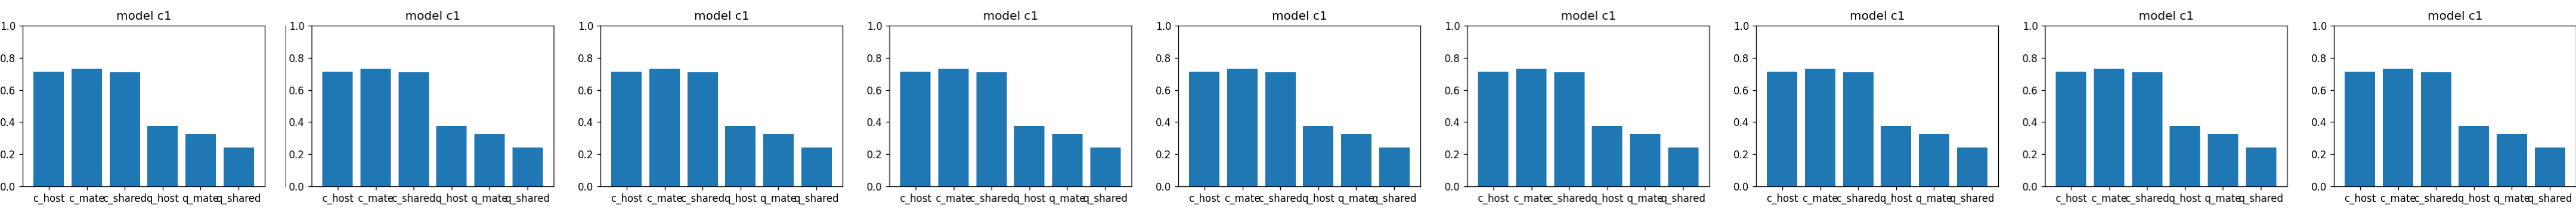

In [64]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
parallax_views(img_paths[0], n_views=9, max_shift=18)


In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HoloSynHeads(nn.Module):
    def __init__(self, p_t, p_i, p_a, p_v, h_enc):
        super().__init__()
        self.p_t = p_t
        self.p_i = p_i
        self.p_a = p_a
        self.p_v = p_v
        self.h_enc = h_enc

    def forward(self, E_t_aug, E_i, E_a, E_v, H):
        # Returns shared-space embeddings (all normalized)
        zt = self.p_t(E_t_aug)
        zi = self.p_i(E_i)
        za = self.p_a(E_a)
        zv = self.p_v(E_v)
        zh = self.h_enc(H)
        return zt, zi, za, zv, zh


In [66]:
bundle = HoloSynHeads(p_t, p_i, p_a, p_v, h_enc).to(torch_device).eval()

torch.save(
    {
        "state_dict": bundle.state_dict(),
        "dims": {
            "E_t_aug": E_t_aug.shape[1],
            "E_i": E_i.shape[1],
            "E_a": E_a.shape[1],
            "E_v": E_v.shape[1],
            "H_T": H.shape[1],
            "H_C": H.shape[2],
        },
    },
    "holosyn_heads.pt"
)
print("Saved holosyn_heads.pt")

Saved holosyn_heads.pt


In [67]:
compiled_bundle = torch.compile(bundle, mode="max-autotune")  # or mode="reduce-overhead"
compiled_bundle = compiled_bundle.eval()

# sanity forward
with torch.no_grad():
    zt, zi, za, zv, zh = compiled_bundle(E_t_aug, E_i, E_a, E_v, H)
print("Compiled forward OK:", zt.shape, zh.shape)


WARNING    /usr/local/lib/python3.12/dist-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()
 [py.warnings]
  return torch._C._get_cublas_allow_tf32()

W0218 12:19:43.097000 285 torch/_inductor/utils.py:1558] [0/0] Not enough SMs to use max_autotune_gemm mode


Compiled forward OK: torch.Size([49, 256]) torch.Size([49, 256])


In [68]:
compiled_bundle = torch.compile(bundle, mode="max-autotune")  # or mode="reduce-overhead"
compiled_bundle = compiled_bundle.eval()

# sanity forward
with torch.no_grad():
    zt, zi, za, zv, zh = compiled_bundle(E_t_aug, E_i, E_a, E_v, H)
print("Compiled forward OK:", zt.shape, zh.shape)

Compiled forward OK: torch.Size([49, 256]) torch.Size([49, 256])


In [69]:
compiled_bundle = torch.compile(bundle, mode="reduce-overhead")


In [70]:
example_inputs = (E_t_aug[:1], E_i[:1], E_a[:1], E_v[:1], H[:1])
ts = torch.jit.trace(bundle, example_inputs)
ts.save("holosyn_heads.torchscript.pt")
print("Saved holosyn_heads.torchscript.pt")


Saved holosyn_heads.torchscript.pt


In [71]:
example_inputs = (E_t_aug[:1], E_i[:1], E_a[:1], E_v[:1], H[:1])
ts = torch.jit.trace(bundle, example_inputs)
ts.save("holosyn_heads.torchscript.pt")
print("Saved holosyn_heads.torchscript.pt")


Saved holosyn_heads.torchscript.pt


In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HoloSynHeads(nn.Module):
    def __init__(self, p_t, p_i, p_a, p_v, h_enc):
        super().__init__()
        self.p_t = p_t
        self.p_i = p_i
        self.p_a = p_a
        self.p_v = p_v
        self.h_enc = h_enc

    def forward(self, E_t_aug, E_i, E_a, E_v, H):
        zt = self.p_t(E_t_aug)
        zi = self.p_i(E_i)
        za = self.p_a(E_a)
        zv = self.p_v(E_v)
        zh = self.h_enc(H)
        return zt, zi, za, zv, zh

heads = HoloSynHeads(p_t, p_i, p_a, p_v, h_enc).to(torch_device).eval()

# optional compile (heads only; stable)
# heads = torch.compile(heads, mode="reduce-overhead")

In [73]:
import numpy as np
import torch
import torch.nn.functional as F
import soundfile as sf

class HoloSynInfer:
    def __init__(
        self,
        heads,
        embed_text_fn,
        embed_image_fn,
        embed_audio_fn,
        embed_video_fn,
        torch_device,
        # optional: synaptic + quantum augmenters (can be None)
        synaptic_fn=None,   # brian2_rate_features
        quantum_fn=None,    # quantum_features
        syn_sim_ms=25.0,
        q_n_qubits=8,
        q_reps=2,
        # synthetic haptics generator (callable)
        synth_haptics_fn=None
    ):
        self.heads = heads.eval()
        self.embed_text = embed_text_fn
        self.embed_image = embed_image_fn
        self.embed_audio = embed_audio_fn
        self.embed_video = embed_video_fn
        self.torch_device = torch_device

        self.synaptic_fn = synaptic_fn
        self.quantum_fn = quantum_fn
        self.syn_sim_ms = syn_sim_ms
        self.q_n_qubits = q_n_qubits
        self.q_reps = q_reps

        self.synth_haptics_fn = synth_haptics_fn

    def _augment_text(self, E_t: torch.Tensor) -> torch.Tensor:
        """
        E_t: (1, D) torch tensor
        returns E_t_aug: (1, D + syn + q) torch tensor
        If synaptic_fn/quantum_fn are None -> returns E_t unchanged.
        """
        if (self.synaptic_fn is None) and (self.quantum_fn is None):
            return E_t

        E_np = E_t.detach().cpu().numpy().astype(np.float32)
        parts = [E_np]

        if self.synaptic_fn is not None:
            # use first 128 dims for speed (adjust if you want)
            S = self.synaptic_fn(E_np[:, :128], sim_ms=self.syn_sim_ms)
            parts.append(S)

        if self.quantum_fn is not None:
            Q = self.quantum_fn(E_np[:, :8], n_qubits=self.q_n_qubits, reps=self.q_reps)
            parts.append(Q)

        E_aug = np.concatenate(parts, axis=1).astype(np.float32)
        E_aug = torch.tensor(E_aug, device=self.torch_device)
        return F.normalize(E_aug, dim=-1)

    def _haptics_to_tensor(self, haptics_np: np.ndarray) -> torch.Tensor:
        """
        haptics_np: (T, C) float32
        returns: (1, T, C) torch tensor
        """
        if haptics_np.ndim != 2:
            raise ValueError("haptics_np must be (T, C)")
        return torch.tensor(haptics_np[None, ...], dtype=torch.float32, device=self.torch_device)

    @torch.no_grad()
    def infer(
        self,
        text: str | None = None,
        image_path: str | None = None,
        audio_path: str | None = None,
        video_path: str | None = None,
        haptics_np: np.ndarray | None = None,
        force_synth_haptics: bool = False,
        synth_T: int = 200
    ):
        """
        Returns dict with:
          - zt, zi, za, zv, zh (each (1,256) depending on your heads)
          - plus raw modality embeddings E_* (useful for debugging)
        """
        # --- Text ---
        if text is None:
            text = ""
        E_t = self.embed_text([text])                  # (1, Dt)
        E_t = E_t.to(self.torch_device)
        E_t_aug = self._augment_text(E_t)             # (1, Dt_aug)

        # --- Image ---
        if image_path is None:
            # dummy zero vector if missing (keeps pipeline stable)
            E_i = torch.zeros((1, self.heads.p_i.net[0].in_features), device=self.torch_device)
        else:
            E_i = self.embed_image([image_path])      # (1, Di)
            E_i = E_i.to(self.torch_device)

        # --- Audio ---
        if audio_path is None:
            E_a = torch.zeros((1, self.heads.p_a.net[0].in_features), device=self.torch_device)
        else:
            E_a = self.embed_audio([audio_path])      # (1, Da)
            E_a = E_a.to(self.torch_device)

        # --- Video ---
        if video_path is None:
            E_v = torch.zeros((1, self.heads.p_v.net[0].in_features), device=self.torch_device)
        else:
            E_v = self.embed_video([video_path])      # (1, Dv)
            E_v = E_v.to(self.torch_device)

        # --- Haptics (real or synthetic) ---
        if (haptics_np is None) or force_synth_haptics:
            if self.synth_haptics_fn is None:
                # default: zeros if no generator provided
                H = torch.zeros((1, synth_T, 3), device=self.torch_device)
            else:
                # if audio exists, drive haptics from audio energy; else from text only
                H_np = self.synth_haptics_fn(audio_path=audio_path, text=text, T=synth_T)
                H = self._haptics_to_tensor(H_np)
        else:
            H = self._haptics_to_tensor(haptics_np)

        # --- Heads (shared space) ---
        zt, zi, za, zv, zh = self.heads(E_t_aug, E_i, E_a, E_v, H)

        return {
            "zt": zt, "zi": zi, "za": za, "zv": zv, "zh": zh,
            "E_t": E_t, "E_t_aug": E_t_aug, "E_i": E_i, "E_a": E_a, "E_v": E_v, "H": H
        }


In [74]:
import numpy as np
import soundfile as sf

def synth_haptics(audio_path: str | None, text: str, T: int = 200) -> np.ndarray:
    # channels: vib, pulse, force in [0,1]
    if audio_path is not None:
        audio, sr = sf.read(audio_path, dtype="float32", always_2d=True)
        wav = audio.mean(axis=1)  # (n,)
        hop = max(1, len(wav) // T)
        env = np.array([np.mean(np.abs(wav[i*hop:(i+1)*hop])) if (i*hop) < len(wav) else 0.0 for i in range(T)],
                       dtype=np.float32)
        env = (env - env.min()) / (env.max() - env.min() + 1e-8)
    else:
        # deterministic pseudo-envelope from text
        seed = (hash(text) % 10_000_000)
        rng = np.random.default_rng(seed)
        env = rng.random(T, dtype=np.float32)

    # simple “sentiment proxy”: more positive if more exclamation marks / happy tokens
    pos_hint = float(text.count("!") + text.lower().count("good") + text.lower().count("love"))
    sent = 1.0 / (1.0 + np.exp(-(pos_hint - 1.0)))  # squashed to (0,1)

    vib   = np.clip(0.15 + 0.85*(0.65*env + 0.35*sent), 0, 1)
    pulse = np.clip((1.0 - sent) * (0.25 + 0.75*env), 0, 1)
    force = np.clip(0.10 + 0.90*(0.75*env + 0.25*sent), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)


In [ ]:
infer = HoloSynInfer(
    heads=heads,
    embed_text_fn=embed_text,
    embed_image_fn=embed_images,
    embed_audio_fn=lambda ps: embed_audio(ps),   # your whisper embedding fn
    embed_video_fn=lambda ps: embed_video(ps),   # your video embedding fn
    torch_device=torch_device,
    synaptic_fn=brian2_rate_features,   # or None for faster inference
    quantum_fn=quantum_features,        # or None for faster inference
    synth_haptics_fn=synth_haptics
)

out = infer.infer(
    text="a calm drifting mood",
    image_path=img_paths[0],
    audio_path=aud_paths[0],
    video_path=vid_paths[0],
    haptics_np=None,              # None -> synthetic
    force_synth_haptics=True
)

out["zt"].shape, out["zh"].shape


(torch.Size([1, 256]), torch.Size([1, 256]))

In [77]:
infer = HoloSynInfer(
    heads=heads,
    embed_text_fn=embed_text,
    embed_image_fn=embed_images,
    embed_audio_fn=lambda ps: embed_audio(ps),   # your whisper embedding fn
    embed_video_fn=lambda ps: embed_video(ps),   # your video embedding fn
    torch_device=torch_device,
    synaptic_fn=brian2_rate_features,   # or None for faster inference
    quantum_fn=quantum_features,        # or None for faster inference
    synth_haptics_fn=synth_haptics
)

out = infer.infer(
    text="a calm drifting mood",
    image_path=img_paths[0],
    audio_path=aud_paths[0],
    video_path=vid_paths[0],
    haptics_np=None,              # None -> synthetic
    force_synth_haptics=True
)

@torch.no_grad()
def cosine_sim(a, b):
    a = F.normalize(a, dim=-1); b = F.normalize(b, dim=-1)
    return (a @ b.T)

# similarity between text and video embedding in shared space
sim_tv = cosine_sim(out["zt"], out["zv"]).item()
sim_ti = cosine_sim(out["zt"], out["zi"]).item()
sim_ta = cosine_sim(out["zt"], out["za"]).item()
sim_th = cosine_sim(out["zt"], out["zh"]).item()

(sim_tv, sim_ti, sim_ta, sim_th)

(-0.2534184455871582,
 -0.18718264997005463,
 -0.066746287047863,
 -0.27575254440307617)

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ZFuse(nn.Module):
    """
    Fuses modality embeddings into a single latent Z by weighted average.
    You can learn these weights later; for now, keep them simple.
    """
    def __init__(self, d=256):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(5))  # t,i,a,v,h weights (learnable)

    def forward(self, zt=None, zi=None, za=None, zv=None, zh=None):
        zs = []
        ws = []
        weights = torch.softmax(self.logits, dim=0)  # (5,)
        # order: t,i,a,v,h
        if zt is not None: zs.append(zt); ws.append(weights[0])
        if zi is not None: zs.append(zi); ws.append(weights[1])
        if za is not None: zs.append(za); ws.append(weights[2])
        if zv is not None: zs.append(zv); ws.append(weights[3])
        if zh is not None: zs.append(zh); ws.append(weights[4])

        if len(zs) == 0:
            raise ValueError("No modalities provided to fuse.")

        Z = 0.0
        wsum = 0.0
        for z, w in zip(zs, ws):
            Z = Z + w * z
            wsum = wsum + w
        Z = Z / (wsum + 1e-8)
        return F.normalize(Z, dim=-1)

class HapticsDecoder(nn.Module):
    """
    Decode a shared latent Z -> haptic command sequence (T,3).
    Output channels: [vibration, pulse, force] in [0,1].
    """
    def __init__(self, z_dim=256, hidden=256, out_ch=3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.out = nn.Linear(hidden, out_ch)

    def forward(self, Z, T=200):
        # Z: (B, z_dim)
        h = self.fc(Z)              # (B, hidden)
        # replicate over time
        hT = h.unsqueeze(1).repeat(1, T, 1)  # (B,T,hidden)
        y = torch.sigmoid(self.out(hT))      # (B,T,3)
        return y


In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ZFuse(nn.Module):
    """
    Fuses modality embeddings into a single latent Z by weighted average.
    You can learn these weights later; for now, keep them simple.
    """
    def __init__(self, d=256):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(5))  # t,i,a,v,h weights (learnable)

    def forward(self, zt=None, zi=None, za=None, zv=None, zh=None):
        zs = []
        ws = []
        weights = torch.softmax(self.logits, dim=0)  # (5,)
        # order: t,i,a,v,h
        if zt is not None: zs.append(zt); ws.append(weights[0])
        if zi is not None: zs.append(zi); ws.append(weights[1])
        if za is not None: zs.append(za); ws.append(weights[2])
        if zv is not None: zs.append(zv); ws.append(weights[3])
        if zh is not None: zs.append(zh); ws.append(weights[4])

        if len(zs) == 0:
            raise ValueError("No modalities provided to fuse.")

        Z = 0.0
        wsum = 0.0
        for z, w in zip(zs, ws):
            Z = Z + w * z
            wsum = wsum + w
        Z = Z / (wsum + 1e-8)
        return F.normalize(Z, dim=-1)

class HapticsDecoder(nn.Module):
    """
    Decode a shared latent Z -> haptic command sequence (T,3).
    Output channels: [vibration, pulse, force] in [0,1].
    """
    def __init__(self, z_dim=256, hidden=256, out_ch=3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.out = nn.Linear(hidden, out_ch)

    def forward(self, Z, T=200):
        # Z: (B, z_dim)
        h = self.fc(Z)              # (B, hidden)
        # replicate over time
        hT = h.unsqueeze(1).repeat(1, T, 1)  # (B,T,hidden)
        y = torch.sigmoid(self.out(hT))      # (B,T,3)
        return y


In [86]:
fuse = ZFuse(d=256).to(torch_device).eval()
hdec = HapticsDecoder(z_dim=256).to(torch_device).eval()

# optional compile these too:
# fuse = torch.compile(fuse, mode="reduce-overhead")
# hdec = torch.compile(hdec, mode="reduce-overhead")

infer = HoloSynInfer(
    heads=heads,
    embed_text_fn=embed_text,
    embed_image_fn=embed_images,
    embed_audio_fn=lambda ps: embed_audio(ps),
    embed_video_fn=lambda ps: embed_video(ps),
    torch_device=torch_device,
    synaptic_fn=brian2_rate_features,   # set None for faster inference
    quantum_fn=quantum_features,        # set None for faster inference
    synth_haptics_fn=synth_haptics
)

In [87]:
out = infer.infer(
    text="tense mood, accelerating energy",
    image_path=img_paths[0],
    audio_path=aud_paths[0],
    video_path=vid_paths[0],
    haptics_np=None,
    force_synth_haptics=True,
    synth_T=200
)

# Perform fusion and decoding here
Z_fused = fuse(
    zt=out["zt"].clone(),
    zi=out["zi"].clone(),
    za=out["za"].clone(),
    zv=out["zv"].clone(),
    zh=out["zh"].clone()
)
H_out = hdec(Z_fused, T=200)

out["Z_fused"] = Z_fused
out["H_out"] = H_out

print("Z_fused:", out["Z_fused"].shape)
print("H_out:", out["H_out"].shape)  # (1,200,3)

Z_fused: torch.Size([1, 256])
H_out: torch.Size([1, 200, 3])


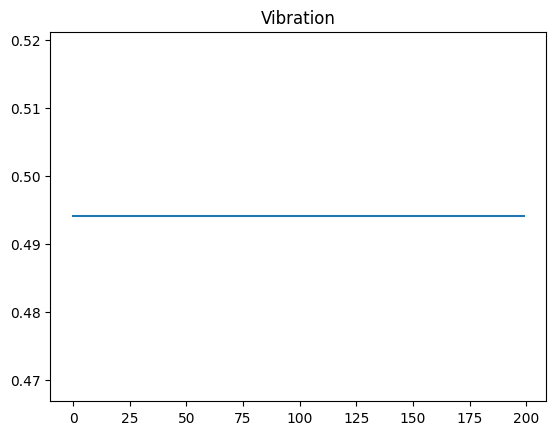

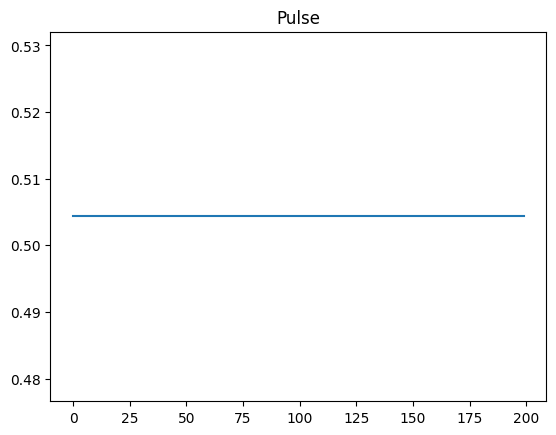

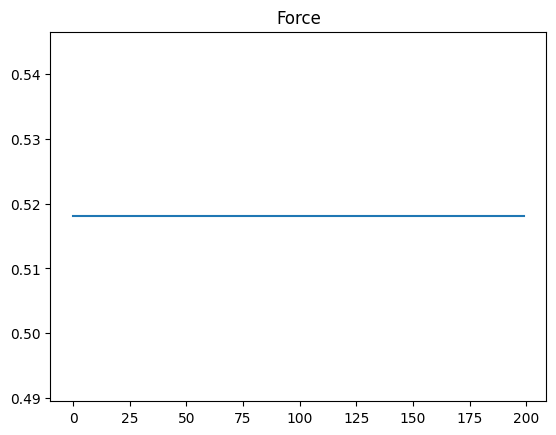

In [88]:
import matplotlib.pyplot as plt
H = out["H_out"].squeeze(0).detach().cpu().numpy()  # (T,3)

plt.figure()
plt.plot(H[:,0]); plt.title("Vibration")
plt.figure()
plt.plot(H[:,1]); plt.title("Pulse")
plt.figure()
plt.plot(H[:,2]); plt.title("Force")
plt.show()


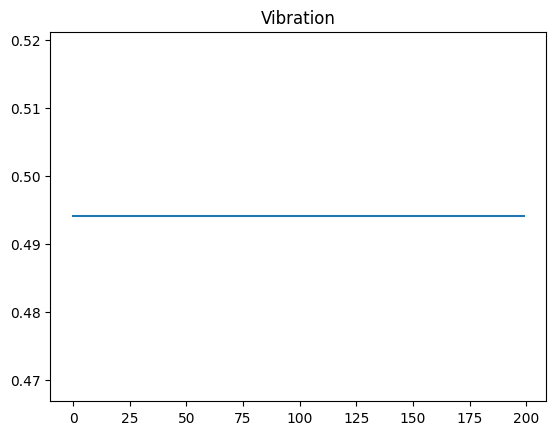

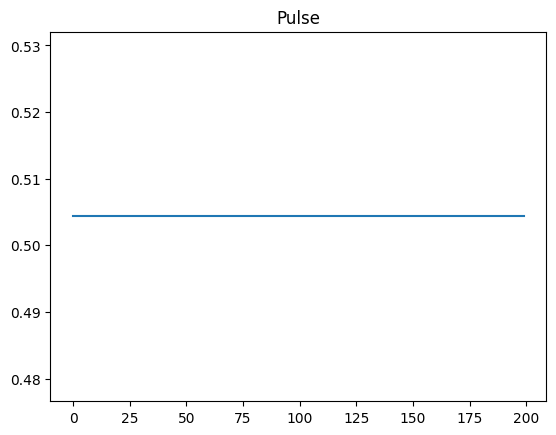

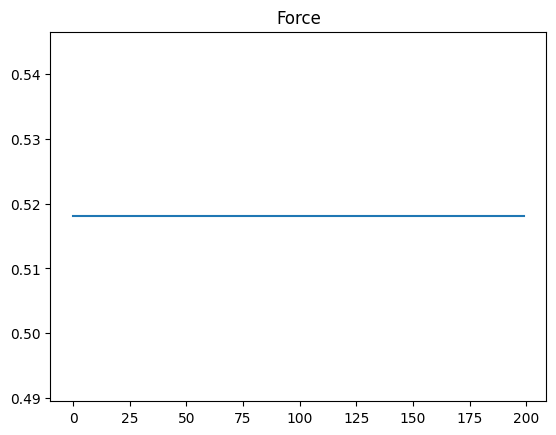

In [89]:
import matplotlib.pyplot as plt
H = out["H_out"].squeeze(0).detach().cpu().numpy()  # (T,3)

plt.figure()
plt.plot(H[:,0]); plt.title("Vibration")
plt.figure()
plt.plot(H[:,1]); plt.title("Pulse")
plt.figure()
plt.plot(H[:,2]); plt.title("Force")
plt.show()

In [96]:
!zip -r ./synthmodelfixed.zip /content

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/.last_update_check.json (deflated 25%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.02.06/ (stored 0%)
  adding: content/.config/logs/2026.02.06/14.31.35.535753.log (deflated 58%)
  adding: content/.config/logs/2026.02.06/14.31.45.734270.log (deflated 56%)
  adding: content/.config/logs/2026.02.06/14.30.32.592228.log (deflated 92%)
  adding: content/.config/logs/2026.02.06/14.31.44.938153.log (deflated 57%)
  adding: content/.config/logs/2026.02.06/14.31.19.332851.log (deflated 58%)
  adding: content/.config/logs/2026.02.06/14.31.28.771044.log (deflated 86%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/configurations/ (stored 0%)
  adding: co

In [97]:
from google.colab import files
files.download("/content/synthmodelfixed.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>